In [1]:
import cfe
import scanpy as sc

cfe.settings.backend = "python_function"
cfe.logger.setLevel("DEBUG")

[2025年07月15日 16时10分52秒] INFO                                                                                 
                                          _____     _ _ ______    _       ______            _                      
                                         / ____|   | | |  ____|  | |     |  ____|          | |                     
                                        | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __  
                                        | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__| 
                                        | |___|  __/ | | | | (_| | ||  __/ |____ >  <| |_) | | (_) | | |  __/ |    
                                         \_____\___|_|_|_|  \__,_|\__\___|______/_/\_\ .__/|_|\___/|_|  \___|_|    
                                                                                     | |                           
                                                                              

R[write to console]: 错误: ignoring SIGPIPE signal



数据

In [2]:
cluster_key = "clusters"
fadata = cfe.data.read_pancrease(n_obs=500 ,save_cluster_key=cluster_key)
fadata

[2025年07月15日 16时10分53秒] DEBUG    sample 1 cells for every cluster                                            
                        DEBUG    sample random cells                                                               
                        DEBUG    Create a FateAnnData object from an existing AnnData object.                      
                        DEBUG    FateAnnData add_trajectory                                                        


AnnData object with n_obs × n_vars = 500 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    uns: 'cfe'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'count'

[2025年07月15日 16时10分54秒] DEBUG    plot_trajectory                                                             
                        DEBUG    add waypoints                                                                     
                        DEBUG    FateAnnData add_waypoints                                                         
[2025年07月15日 16时10分55秒] DEBUG    add waypoints shape is (210, 500), finished!                                


<Axes: title={'center': 'milestone_color'}, xlabel='UMAP1', ylabel='UMAP2'>

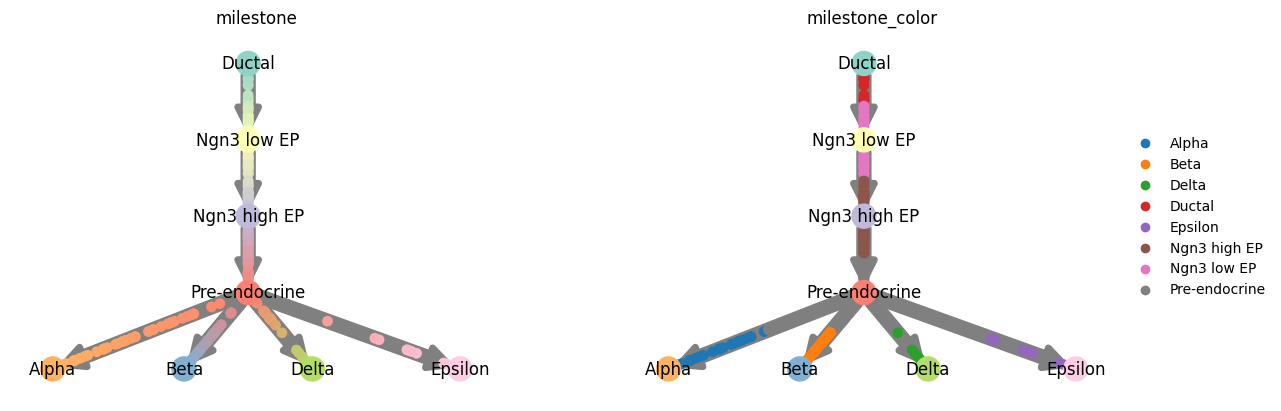

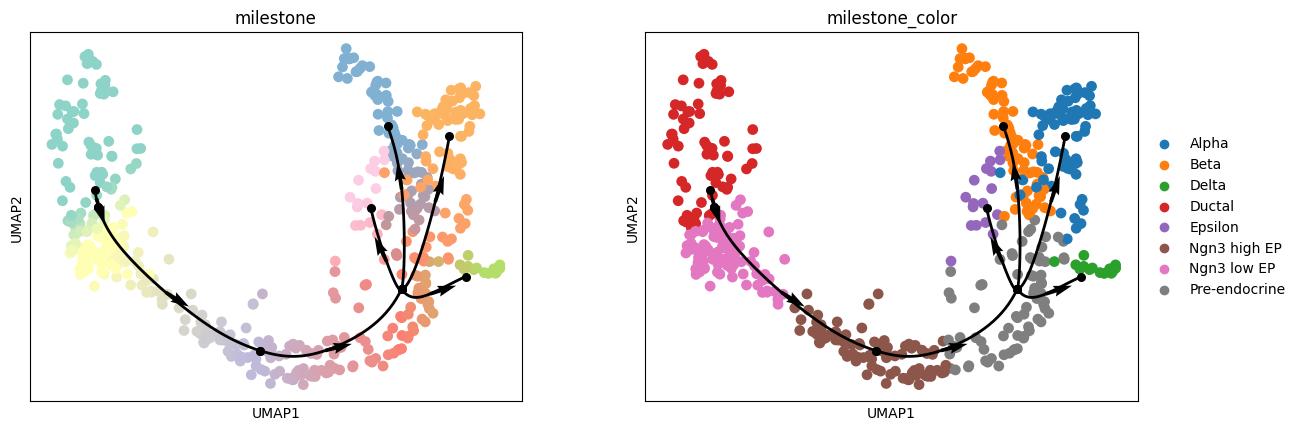

In [3]:
cluster_key = "milestone_color"
fadata.group_onto_nearest_milestones(cluster_key=cluster_key) # new cluster color

basis = "umap"
cluster_key_list = ["milestone", cluster_key]
cfe.plot.plot_graph(fadata, color=cluster_key_list)
cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)

[2025年07月15日 16时10分58秒] DEBUG    FunctionBackend __init__                                                    
                        INFO     Loaded function: <function cf_scvelo at 0x7fb53008a830> from                      
                                 /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_
                                 scvelo.py                                                                         
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x7fb47b744f10>                                                                   
                        WARNING                                                                                    
                                                 Prior information groups_id is optional, but missing from dataset 
                                 20250715_161053__FateAnnData__10R0OsoU9k.    

  0%|          | 0/500 [00:00<?, ?cells/s]

    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
[2025年07月15日 16时11分01秒] DEBUG    Add trajectory by wrapper type: velocity                                    
                        DEBUG    Wrapper type: velocity                                                            
                        DEBUG    Create a FateAnnData object from an existing AnnData object.                      
                        DEBUG    filterd adata: AnnData object with n_obs × n_vars = 500 × 2000                    
                                     obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'milestone_color',
                                 'milestone'                                                                       
                                     uns: 'cfe', 'milestone_colors', 'milestone_color_colors',                     
                                 'milestone_color_dict'                                

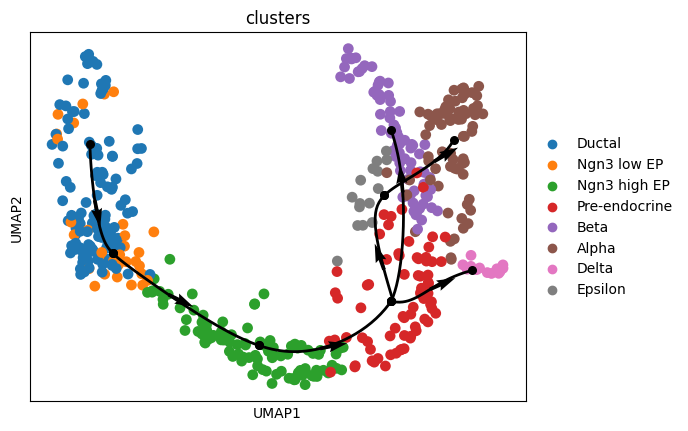

In [ ]:
prior_information = {}
fadata.add_prior_information(**prior_information)  # add prior information to fadata
parameters = {}

method_name_list = ["scvelo"]

for method_name in method_name_list:
    method = cfe.method.FateMethod(method_name=method_name)
    method.infer_trajectory(fadata, parameters=parameters)
    # TODO: 细胞太少会报错
    cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)

                        INFO     find wrapper type: velocity                                                       


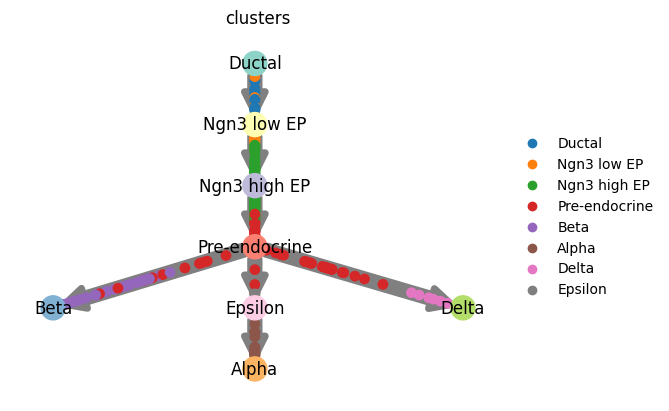

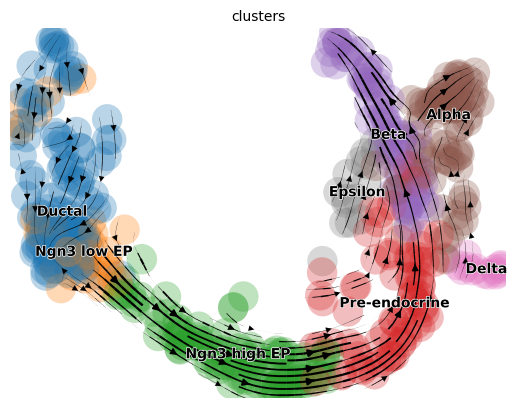

In [5]:
cfe.plot.plot_graph(fadata, color=cluster_key_list)
cfe.plot.plot_wrapper(fadata)